# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [1]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_histogram

from ewfs import EWFS, decode_results, MAJORITY_VOTE, post_select_results
from ewfs.setting import PEEK, REVERSE_1
from ewfs.noise_models import depolarizing_model

## Sanity checks (for majority vote approach)

In [5]:
alice_setting = PEEK
bob_setting = REVERSE_1
charlie_size = 2
debbie_size = 0
strategy = MAJORITY_VOTE

ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
    friend_state="ghz",
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

KeyError: 57

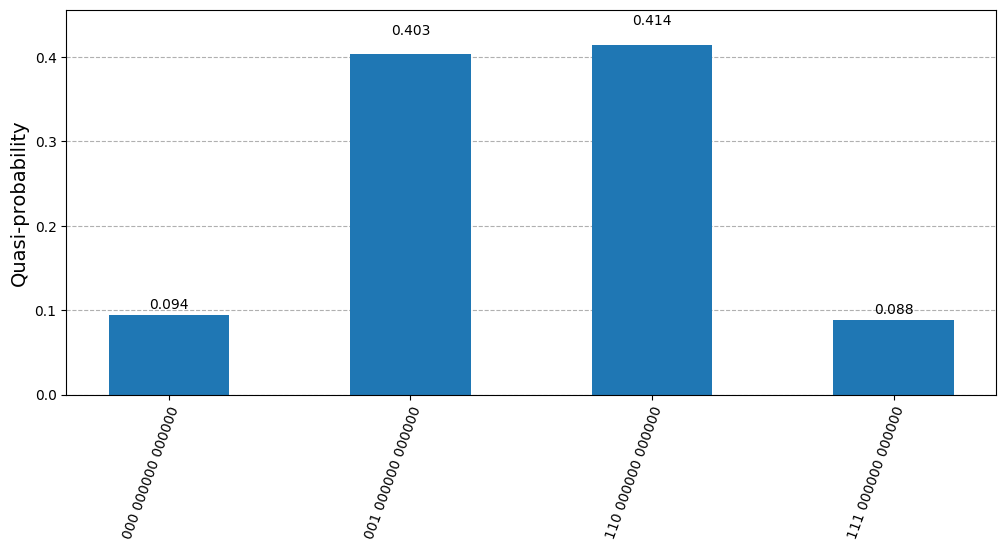

In [3]:
# lots of noise
noise_model = depolarizing_model(circ=qc, single_qubit_error_rate=0.001, two_qubit_error_rate=0.01, meas_error_rate=0.01)
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=None)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

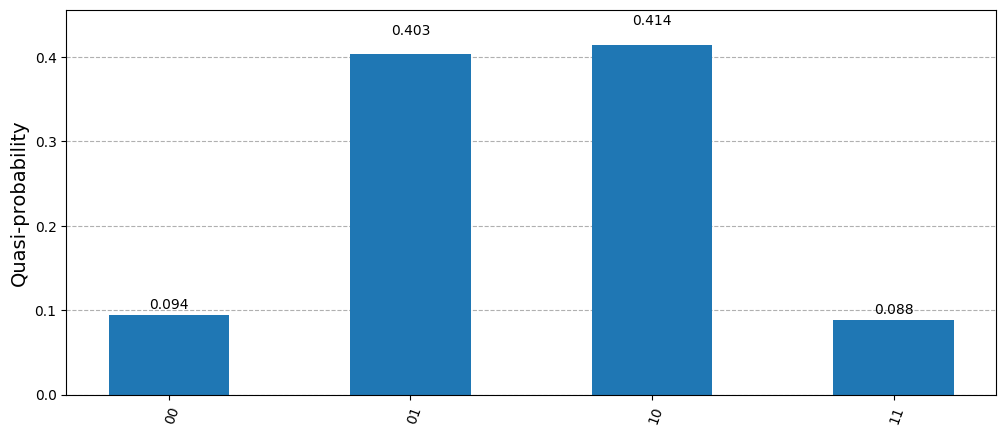

In [4]:
results = {(alice_setting, bob_setting): probabilities}
post_selected_results = post_select_results(results, charlie_size, debbie_size, 6, 6)
dec_res = decode_results(post_selected_results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

In [ ]:
results

{('peek', 'reverse_1'): {'111 000000 000000': 0.0883,
  '001 000000 000000': 0.4031,
  '000 000000 000000': 0.0942,
  '110 000000 000000': 0.4144}}

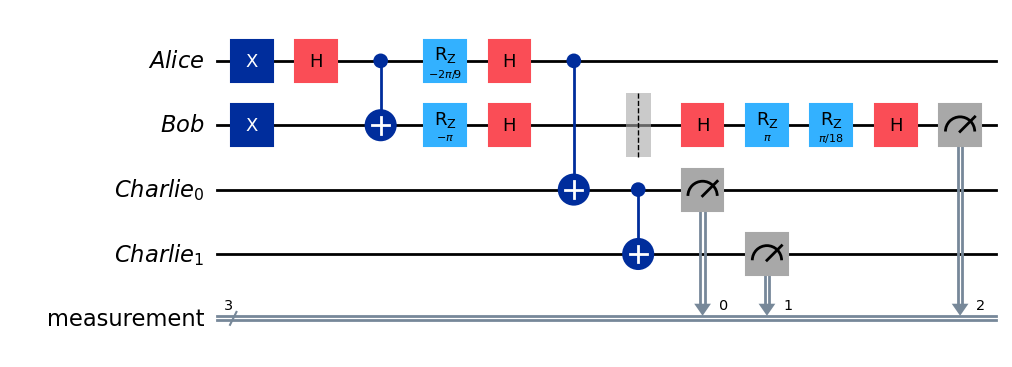

In [14]:
alice_setting = PEEK
bob_setting = REVERSE_1
charlie_size = 2
debbie_size = 0
strategy = MAJORITY_VOTE


# Now using the cnot_ladder approach
ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
    friend_state="cnot_ladder",
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

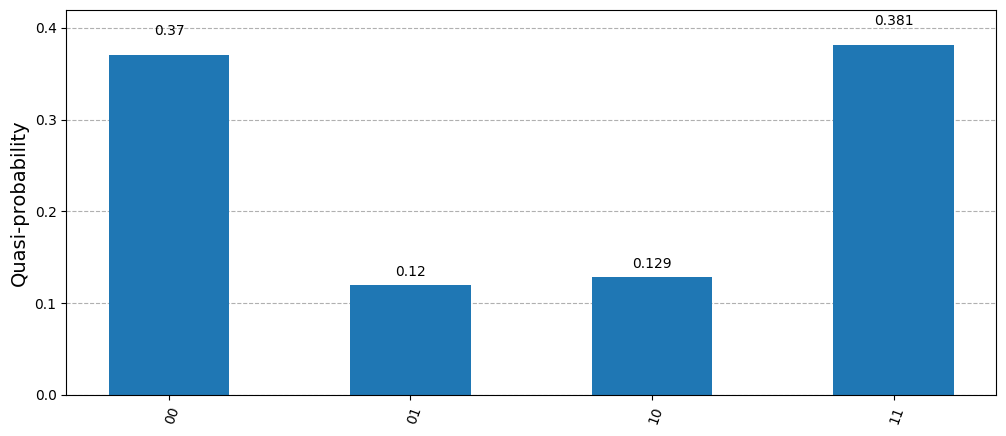

In [11]:
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=None)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

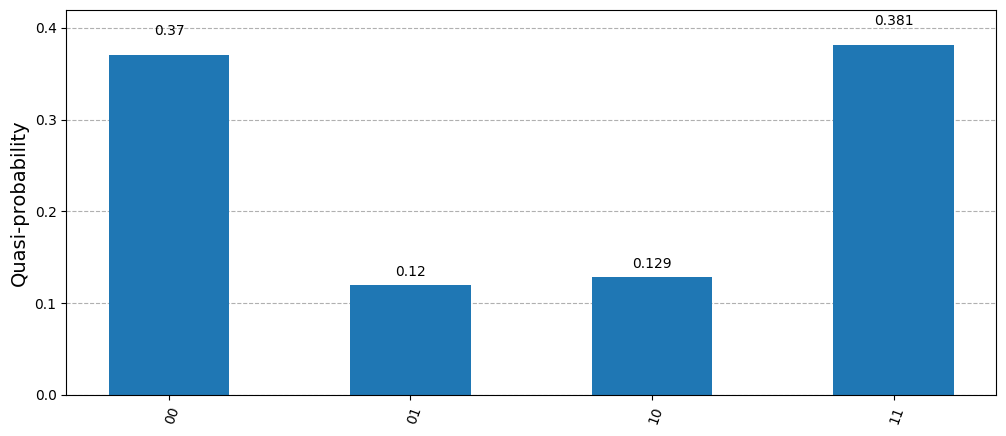

In [12]:
results = {(alice_setting, bob_setting): probabilities}
dec_res = decode_results(results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

## Experiment

Run EWFS experiment for a specific number of shots, trials, and over a range of friend sizes.

#### Settings

In [9]:
from ewfs import run_experiment, SEMI_BRUKNER_SETTINGS

run_experiment(settings=SEMI_BRUKNER_SETTINGS, strategy="random")

Trial 1 out of 2 for task of 1_1
Task with task ID: 2fd05381-f418-40a7-affd-faf274cc86f0

Trial 2 out of 2 for task of 1_1
Task with task ID: 1885325e-28b9-429f-9ff9-cc33de61472b

Trial 1 out of 2 for task of 2_1
Task with task ID: bfe8e324-d4e6-4365-9658-a1d80f5e2965

Trial 2 out of 2 for task of 2_1
Task with task ID: b2501eb3-582d-4b0c-9cee-1f77a4985436

Processing trial 1 for task with task ID: 2fd05381-f418-40a7-affd-faf274cc86f0
Results: {('peek', 'reverse_1'): {'01': 0.4152, '10': 0.4079, '11': 0.0851, '00': 0.0918}, ('peek', 'reverse_2'): {'10': 0.0868, '00': 0.4098, '11': 0.4152, '01': 0.0882}, ('reverse_2', 'reverse_1'): {'01': 0.4399, '00': 0.0569, '10': 0.4459, '11': 0.0573}, ('reverse_2', 'reverse_2'): {'10': 0.4369, '01': 0.4488, '11': 0.0569, '00': 0.0574}}
semi_brukner=0.8392 -- is violated: True
Violations: {'semi_brukner': 0.8392}

Post-processed results: defaultdict(<function run_experiment.<locals>.<lambda> at 0x1260e42c0>, {'1_1': defaultdict(<class 'list'>, {'semi

defaultdict(<function ewfs.experiment.run_experiment.<locals>.<lambda>()>,
            {'1_1': defaultdict(list,
                         {'semi_brukner': [0.8392, 0.8316000000000003]}),
             '2_1': defaultdict(list,
                         {'semi_brukner': [0.8188, 0.8355999999999999]})})